In [1]:
import matplotlib.pyplot
import pandas
import tarfile

In [42]:
# Colorblind safe, print friendly
colors = {
    'latency'  : '#1b9e77',
    'replicas' : '#d95f02',
    'other'    : '#7570b3',
}

def parse_replicas(file_path : str) -> list[int]:
    replicas : list[int] = []

    with (open(f"{file_path}/replicas.log")) as file:
        for line in file:
            parts : list[str] = line.split()
            if "crust" in parts[0]:
                replicas.append(int(parts[6]))
    
    return replicas

def plot_replicas(file_path : str) -> None:
    replicas = parse_replicas(file_path)

    matplotlib.pyplot.plot(replicas, color=color['replicas'])
    matplotlib.pyplot.axvline(x = 0, linestyle = '--', color=color['other'])
    matplotlib.pyplot.axvline(x = 60, linestyle = '--', color=color['other'])
    matplotlib.pyplot.axvline(x = 240, linestyle = '--', color=color['other'])
    matplotlib.pyplot.xlabel("Time (s)")
    matplotlib.pyplot.ylabel("Replica Count") 
    matplotlib.pyplot.legend()
    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.show()

def parse_p99(file_path : str) -> pandas.Series:
    columns : list[str] = ['timestamp_ns', 'status', 'latency_ns']
    data_frames : list[pandas.DataFrame] = [
        pandas.read_csv(f"{file_path}/vegeta1.log", usecols=[0, 1, 2], header=None, names=columns),
        pandas.read_csv(f"{file_path}/vegeta2.log", usecols=[0, 1, 2], header=None, names=columns),
        pandas.read_csv(f"{file_path}/vegeta3.log", usecols=[0, 1, 2], header=None, names=columns),
    ]
    combined_data_frame : pandas.DataFrame = pandas.concat(data_frames, ignore_index=True)

    combined_data_frame['timestamp_ns'] = pandas.to_datetime(combined_data_frame['timestamp_ns'], unit='ns')
    combined_data_frame = combined_data_frame.set_index('timestamp_ns')

    #return combined_data_frame['latency_ns'].resample('1s').quantile(0.99).expanding().mean() / 1e6
    return combined_data_frame['latency_ns'].resample('1s').quantile(0.99) / 1e6
    
def plot_p99(file_path : str) -> None:
    latencies = parse_p99(file_path)

    matplotlib.pyplot.plot(latencies.to_numpy(), color=colors['latency'])
    matplotlib.pyplot.axvline(x = 0, linestyle = '--', color=color['other'])
    matplotlib.pyplot.axvline(x = 60, linestyle = '--', color=color['other'])
    matplotlib.pyplot.axvline(x = 240, linestyle = '--', color=color['other'])
    matplotlib.pyplot.xlabel("Time (s)")
    matplotlib.pyplot.ylabel("P99 Latency (ms)")
    matplotlib.pyplot.legend()
    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.show()

def plot(file_path : str) -> None:
    replicas = parse_replicas(file_path)
    latencies = parse_p99(file_path)

    fig, ax1 = matplotlib.pyplot.subplots(figsize=(12, 5))

    ax1.set_xlabel("Time (samples)")
    ax1.set_ylabel("Replicas", color=colors['replicas'])
    ax1.plot(replicas, color=colors['replicas'], label="Replicas")
    ax1.tick_params(axis="y", labelcolor=colors['replicas'])
    ax1.set_xticks(range(0, max(len(replicas), len(latencies)), 60))

    ax2 = ax1.twinx()
    ax2.set_ylabel("Average P99 Latency (ms)", color=colors['latency'])
    ax2.plot(latencies.to_numpy(), color=colors['latency'], label="P99 Latency")
    ax2.tick_params(axis="y", labelcolor=colors['latency'])

    matplotlib.pyplot.axvline(x = 0, linestyle = '--', color=colors['other'])
    matplotlib.pyplot.axvline(x = 60, linestyle = '--', color=colors['other'])
    matplotlib.pyplot.axvline(x = 240, linestyle = '--', color=colors['other'])

    matplotlib.pyplot.title("Replicas vs P99")
    fig.tight_layout()
    fig.show()

/tmp/ipykernel_37224/890210733.py:83: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


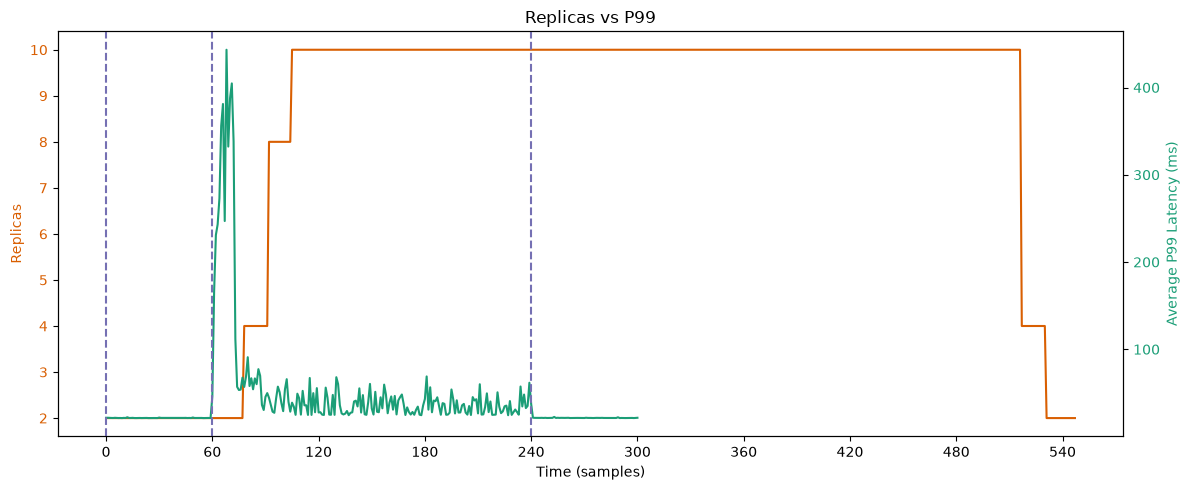

In [43]:
plot(".");